In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [4]:

# Load dataset
df = pd.read_csv("student-por.csv", sep=';')

# Basic inspection
print(df.head())
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (to

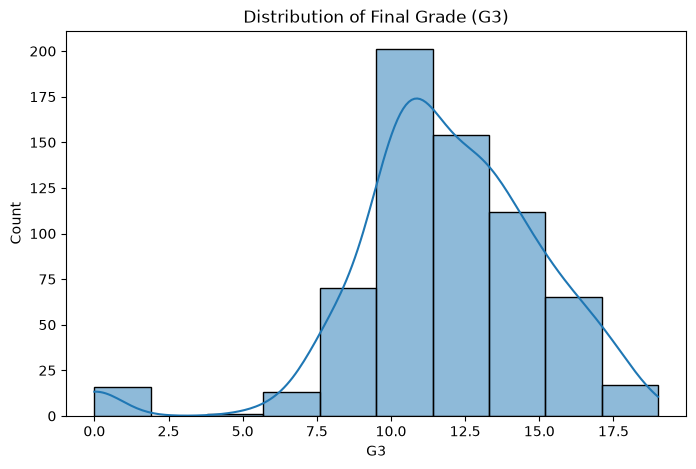

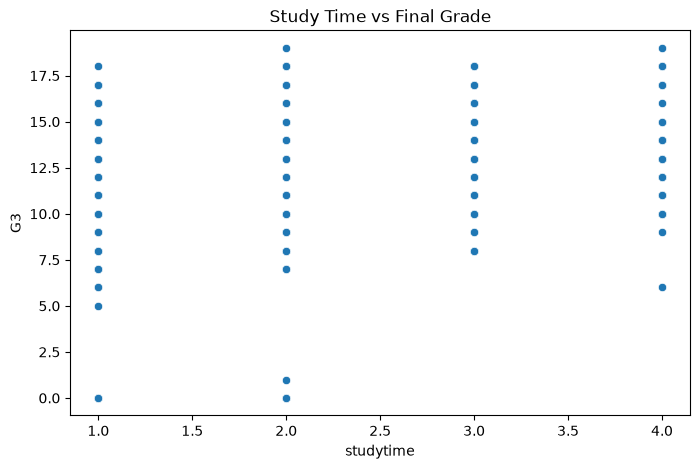

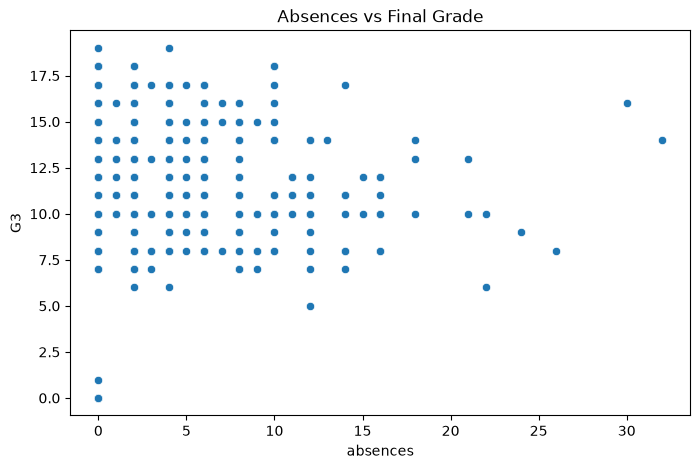

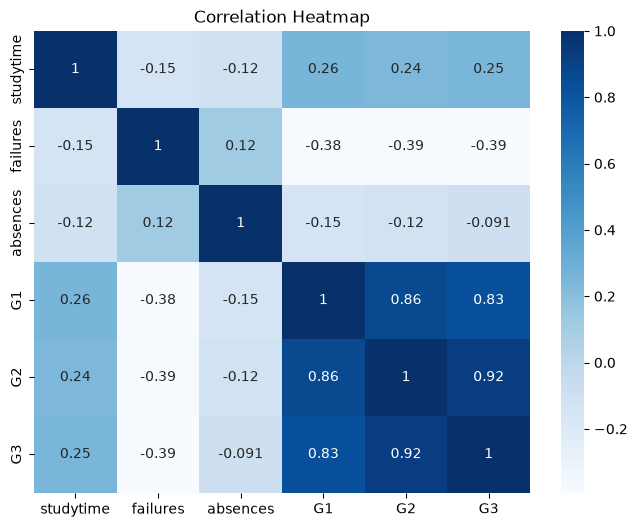

In [5]:

# EDA
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=10, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['studytime'], y=df['G3'])
plt.title("Study Time vs Final Grade")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['absences'], y=df['G3'])
plt.title("Absences vs Final Grade")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['studytime','failures','absences','G1','G2','G3']].corr(),
            annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


In [6]:

# -----------------------------
# Multiple Linear Regression
# -----------------------------
X = df[['studytime', 'failures', 'absences', 'G1', 'G2']]
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("\n--- Multiple Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(results.head(10))



--- Multiple Linear Regression ---
MAE: 0.7462407529568903
MSE: 1.333414833999006
R2 Score: 0.8632635694850659
   Actual  Predicted
0      19  18.597555
1      12  11.351960
2      18  18.677988
3      11  11.246336
4      11  11.714360
5      17  16.835757
6      18  17.624215
7       8   9.165340
8      10  10.499721
9      11  10.529771


In [7]:

# -----------------------------
# Logistic Regression
# -----------------------------
df['pass'] = (df['G3'] >= 10).astype(int)

X_cls = df[['studytime', 'failures', 'absences', 'G1', 'G2']]
y_cls = df['pass']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_cls, y_train_cls)

y_pred_cls = log_model.predict(X_test_cls)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("Confusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))
print("Classification Report:\n", classification_report(y_test_cls, y_pred_cls))




--- Logistic Regression ---
Accuracy: 0.9307692307692308
Confusion Matrix:
 [[ 11   4]
 [  5 110]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71        15
           1       0.96      0.96      0.96       115

    accuracy                           0.93       130
   macro avg       0.83      0.84      0.84       130
weighted avg       0.93      0.93      0.93       130



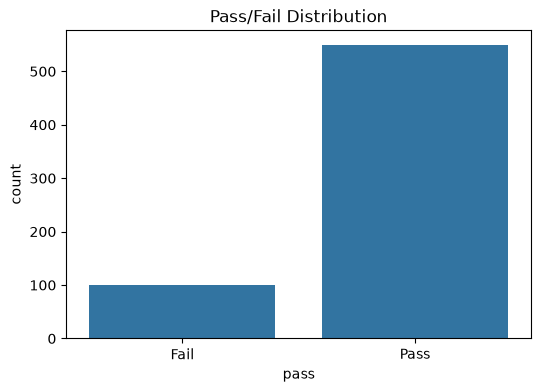

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='pass', data=df)
plt.title("Pass/Fail Distribution")
plt.xticks([0,1], ['Fail', 'Pass'])
plt.show()


In [10]:
# ========================
# Test Model with Custom Input
# ========================

print("=" * 50)
print("TEST THE MODEL WITH YOUR OWN INPUT")
print("=" * 50)

# Get user input
print("\nEnter student information:")
studytime = float(input("Study time (1-5): "))
failures = float(input("Number of failures (0-4): "))
absences = float(input("Number of absences (0-93): "))
g1 = float(input("G1 grade (0-20): "))
g2 = float(input("G2 grade (0-20): "))

# Create input dataframe with same feature names as training
user_input = pd.DataFrame({
    'studytime': [studytime],
    'failures': [failures],
    'absences': [absences],
    'G1': [g1],
    'G2': [g2]
})

print("\nUser Input Data:")
print(user_input)

# Predict with Linear Regression
predicted_grade = lr_model.predict(user_input)[0]

# Predict with Logistic Regression
pass_prediction = log_model.predict(user_input)[0]
pass_probability = log_model.predict_proba(user_input)[0]

# Display results
print("\n" + "=" * 50)
print("PREDICTIONS")
print("=" * 50)
print(f"\nLinear Regression - Predicted Final Grade (G3): {predicted_grade:.2f}")
print(f"   (Expected range: 0-20)")

print(f"\nLogistic Regression - Pass/Fail Prediction:")
print(f"   Status: {'PASS ✓' if pass_prediction == 1 else 'FAIL ✗'}")
print(f"   Probability of FAIL: {pass_probability[0]:.2%}")
print(f"   Probability of PASS: {pass_probability[1]:.2%}")

print("\n" + "=" * 50)

TEST THE MODEL WITH YOUR OWN INPUT

Enter student information:

User Input Data:
   studytime  failures  absences    G1    G2
0        4.0       3.0      20.0  19.0  18.0

PREDICTIONS

Linear Regression - Predicted Final Grade (G3): 19.13
   (Expected range: 0-20)

Logistic Regression - Pass/Fail Prediction:
   Status: PASS ✓
   Probability of FAIL: 0.00%
   Probability of PASS: 100.00%

